In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Project: Business Applications Analysis in the United States


## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#findings">Findings</a></li>
<li><a href="#limitations">Limitations</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
# 1. Introduction

Business formation is often used as an indicator of entrepreneurial activity and economic confidence. This project analyzes business application trends in the United States using data from the U.S. Census Bureau's Business Formation Statistics program.

Business applications represent an early signal of entrepreneurial intent, while business formations measure businesses that eventually become operational and begin employing workers. Understanding the relationship between these two indicators can help policymakers, investors, and economic analysts better understand economic trends and business development patterns.

## Problem Statement

Entrepreneurship plays a critical role in economic growth, job creation, and innovation. However, not all business applications result in successful business formations. Understanding how entrepreneurial activity varies across states, industries, and time can provide valuable insights into the factors associated with business growth and economic development.

This project aims to analyze historical trends in business applications and business formations across the United States and investigate whether business applications can serve as a leading indicator of future business formation activity.

## Objectives

- Analyze long-term business application trends.
- Examine the impact of COVID-19.
- Identify sectors driving business formation.
- Compare pre- and post-pandemic periods.

### Research Questions

#### Research Question 1

How have business applications evolved over time in the United States?

#### Research Question 2

Which sectors contribute the most to business formation activity?

#### Research Question 3
which sectors  experienced the largest growth after the COVID-19 pandemic?

#### Research Question 4

How did business application patterns change before and after COVID-19?

## Dataset Description

The dataset used in this project comes from the Business Formation Statistics (BFS) program developed by the U.S. Census Bureau. BFS provides timely and high-frequency information on business applications and business formations across the United States.

The data captures applications for Employer Identification Numbers (EINs), which serve as an early indicator of entrepreneurial activity. In addition, the dataset includes measures of actual and projected business formations derived from these applications.

The monthly BFS dataset covers the period from July 2004 through 2026 and contains information at multiple geographic and industry levels. For this analysis, the data includes observations across U.S. states, industries, and time periods.


### Dataset Structure

The original dataset contains 36,883 observations and 17 variables.

Each row represents a specific combination of:

Geographic area (geo)
Industry sector (naics_sector)
Business indicator (series)
Year (year)

Monthly values are stored across twelve separate columns:

jan, feb, mar, apr, may, jun,
jul, aug, sep, oct, nov, dec

### Business Indicators Included

The dataset contains several indicators related to entrepreneurial activity:

Business Applications (BA)

Applications submitted for an Employer Identification Number (EIN), representing potential new business activity.

High-Propensity Business Applications (HBA)

A subset of business applications with characteristics associated with a higher likelihood of becoming employer businesses.

Business Formations (BF4Q / BF8Q)

The number of businesses that originate from applications and become operational within four or eight quarters.

Projected Business Formations (PBF4Q / PBF8Q)

Model-based estimates of future business formations.

Duration Measures (DUR4Q / DUR8Q)

The average time between a business application and the eventual formation of a business.

### Key Variables

Variable	Description

- geo	Geographic location (United States, states, or regions)
- naics_sector	Industry classification based on the North American Industry Classification System (NAICS)
- series	Business activity metric (e.g., Business Applications, Business Formations)
- year	Calendar year
- jan-dec	Monthly values associated with the selected metric

### Relevance to the Project

This dataset is particularly useful for studying entrepreneurship because it provides both an early indicator of business creation (applications) and a measure of realized business activity (formations). By analyzing these indicators across states, industries, and time periods, it is possible to investigate patterns of entrepreneurial growth and evaluate whether business applications can serve as a leading indicator of future business formation activity.

<a id='wrangling'></a>
# 2. Data Wrangling 

In [2]:
import pandas as pd
df = pd.read_csv("bfs_monthly.csv")

### Dataset dimensions

In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 36883
Columns: 17


**Interpretation**

The dataset contains 36,883 observations and 17 variables. Each observation represents a combination of business formation series, geographic area, industry sector, and year.

In [4]:
df.head()

,sa,naics_sector,series,geo,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
0,U,TOTAL,BA_BA,US,2026,547443,505240,534850,649160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,U,NAICS11,BA_BA,US,2026,4687,5048,4676,4871,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,U,NAICS21,BA_BA,US,2026,524,544,593,687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,U,NAICS22,BA_BA,US,2026,498,586,581,722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,U,NAICS23,BA_BA,US,2026,46834,50799,51361,62652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape

(36883, 17)

In [6]:
df.describe()

,year
count,36883.000000
mean,2014.480167
std,6.428034
min,2004.000000
25%,2009.000000
50%,2014.000000
75%,2020.000000
max,2026.000000


### Variables Description

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36883 entries, 0 to 36882
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   sa            36883 non-null  str  
 1   naics_sector  36883 non-null  str  
 2   series        36883 non-null  str  
 3   geo           36883 non-null  str  
 4   year          36883 non-null  int64
 5   jan           34908 non-null  str  
 6   feb           34908 non-null  str  
 7   mar           34908 non-null  str  
 8   apr           34908 non-null  str  
 9   may           33684 non-null  str  
 10  jun           33684 non-null  str  
 11  jul           35364 non-null  str  
 12  aug           35364 non-null  str  
 13  sep           35364 non-null  str  
 14  oct           35364 non-null  str  
 15  nov           35364 non-null  str  
 16  dec           35364 non-null  str  
dtypes: int64(1), str(16)
memory usage: 4.8 MB


In [8]:
df.dtypes

sa                str
naics_sector      str
series            str
geo               str
year            int64
jan               str
feb               str
mar               str
apr               str
may               str
jun               str
jul               str
aug               str
sep               str
oct               str
nov               str
dec               str
dtype: object

**Interpretation**

The dataset contains categorical variables describing industry, geography, and business formation metrics, together with monthly observations reported by the U.S. Census Bureau.

## Missing Values Assessment

### Identifying Missing Value

In [9]:
df.isna().sum()

sa                 0
naics_sector       0
series             0
geo                0
year               0
jan             1975
feb             1975
mar             1975
apr             1975
may             3199
jun             3199
jul             1519
aug             1519
sep             1519
oct             1519
nov             1519
dec             1519
dtype: int64

### Are These True Missing Values?

In [10]:
df["series"].value_counts()

series
BA_BA       3542
BA_CBA      3542
BA_HBA      3542
BA_WBA      3542
BF_PBF4Q    3542
BF_PBF8Q    3542
BF_SBF4Q    3542
BF_SBF8Q    3542
BF_BF4Q     2926
BF_BF8Q     2772
BF_DUR4Q    1463
BF_DUR8Q    1386
Name: count, dtype: int64

In [11]:
df.groupby("series").count()[["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]]

,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
series,,,,,,,,,,,,
BA_BA,3388,3388,3388,3388,3234,3234,3388,3388,3388,3388,3388,3388
BA_CBA,3388,3388,3388,3388,3234,3234,3388,3388,3388,3388,3388,3388
BA_HBA,3388,3388,3388,3388,3234,3234,3388,3388,3388,3388,3388,3388
BA_WBA,3388,3388,3388,3388,3234,3234,3388,3388,3388,3388,3388,3388
BF_BF4Q,2736,2736,2736,2736,2736,2736,2888,2888,2888,2888,2888,2888
BF_BF8Q,2584,2584,2584,2584,2584,2584,2736,2736,2736,2736,2736,2736
BF_DUR4Q,1368,1368,1368,1368,1368,1368,1444,1444,1444,1444,1444,1444
BF_DUR8Q,1292,1292,1292,1292,1292,1292,1368,1368,1368,1368,1368,1368
BF_PBF4Q,3344,3344,3344,3344,3192,3192,3344,3344,3344,3344,3344,3344


In [12]:
df.groupby("series").agg({
    "jan":"count",
    "feb":"count",
    "mar":"count",
    "apr":"count",
    "may":"count",
    "jun":"count",
    "jul":"count",
    "aug":"count",
    "sep":"count",
    "oct":"count",
    "nov":"count",
    "dec":"count"
})

,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
series,,,,,,,,,,,,
BA_BA,3388,3388,3388,3388,3234,3234,3388,3388,3388,3388,3388,3388
BA_CBA,3388,3388,3388,3388,3234,3234,3388,3388,3388,3388,3388,3388
BA_HBA,3388,3388,3388,3388,3234,3234,3388,3388,3388,3388,3388,3388
BA_WBA,3388,3388,3388,3388,3234,3234,3388,3388,3388,3388,3388,3388
BF_BF4Q,2736,2736,2736,2736,2736,2736,2888,2888,2888,2888,2888,2888
BF_BF8Q,2584,2584,2584,2584,2584,2584,2736,2736,2736,2736,2736,2736
BF_DUR4Q,1368,1368,1368,1368,1368,1368,1444,1444,1444,1444,1444,1444
BF_DUR8Q,1292,1292,1292,1292,1292,1292,1368,1368,1368,1368,1368,1368
BF_PBF4Q,3344,3344,3344,3344,3192,3192,3344,3344,3344,3344,3344,3344


In [13]:
(df.isnull().mean()*100).round(2)

sa              0.00
naics_sector    0.00
series          0.00
geo             0.00
year            0.00
jan             5.35
feb             5.35
mar             5.35
apr             5.35
may             8.67
jun             8.67
jul             4.12
aug             4.12
sep             4.12
oct             4.12
nov             4.12
dec             4.12
dtype: float64

### Preliminary Assessment of Missing Values

A simple inspection of the dataset revealed the presence of missing values in several monthly columns. The percentage of missing values ranges from approximately 4% to 9%, depending on the month. At first glance, these missing values could suggest incomplete data collection. However, a deeper investigation indicates that the missing values are concentrated within specific business formation series rather than being randomly distributed throughout the dataset.

In [14]:
df.nunique()

sa                 2
naics_sector      21
series            12
geo               57
year              23
jan             7832
feb             7834
mar             8010
apr             7807
may             7580
jun             7524
jul             7697
aug             7744
sep             7606
oct             7635
nov             7603
dec             7444
dtype: int64

### Interpretation

Several BFS variables contain missing values because they depend on future business outcomes. Metrics such as BF4Q, BF8Q, DUR4Q, and DUR8Q require observing whether a business becomes operational or survives for multiple quarters after the initial application.

Therefore, the missing values do not appear to be caused by data quality issues. Instead, they reflect the way these indicators are defined and calculated.

In [15]:
df[df["year"] == 2026].head(20)

,sa,naics_sector,series,geo,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
0,U,TOTAL,BA_BA,US,2026,547443,505240,534850,649160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,U,NAICS11,BA_BA,US,2026,4687,5048,4676,4871,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,U,NAICS21,BA_BA,US,2026,524,544,593,687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,U,NAICS22,BA_BA,US,2026,498,586,581,722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,U,NAICS23,BA_BA,US,2026,46834,50799,51361,62652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,U,NAICSMNF,BA_BA,US,2026,7714,7936,7576,9056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,U,NAICS42,BA_BA,US,2026,10548,9438,9034,12925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,U,NAICSRET,BA_BA,US,2026,113205,72640,85806,105976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,U,NAICSTW,BA_BA,US,2026,36903,34613,35409,42936,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,U,NAICS51,BA_BA,US,2026,11318,11368,12675,15593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df[df["year"] == 2026][
    ["jan","feb","mar","apr","may","jun","jul","aug"]
].isnull().mean()*100

jan      0.649351
feb      0.649351
mar      0.649351
apr      0.649351
may    100.000000
jun    100.000000
jul    100.000000
aug    100.000000
dtype: float64

NaN do they have a dependence of year?

In [17]:
df.groupby("year").apply(
    lambda x: x.isnull().mean().mean()*100
)

year
2004    37.809917
2005     0.619835
2006     0.619835
2007     0.619835
2008     0.619835
2009     0.619835
2010     0.619835
2011     0.619835
2012     0.619835
2013     0.619835
2014     0.619835
2015     0.619835
2016     0.619835
2017     0.619835
2018     0.619835
2019     0.619835
2020     0.619835
2021     0.619835
2022     0.563910
2023     0.487013
2024     0.487013
2025     0.487013
2026    50.162338
dtype: float64

The missing values observed in the dataset are not primarily caused by data collection issues. Instead, they reflect the temporal structure of the BFS dataset.

First, the BFS monthly series begins in July 2004, which explains the elevated proportion of missing values observed for the year 2004. Months prior to July 2004 were not collected and therefore appear as missing.

Second, the dataset contains partial observations for 2026. At the time of publication, only data through April 2026 had been released, resulting in missing values for the remaining months of the year.

Finally, a small number of additional missing values are associated with specific business formation indicators that cannot be computed for all periods due to methodological constraints.

Therefore, the missing values largely reflect the design and publication schedule of the dataset rather than data quality problems.

## Frequency of special codes for NaN values

### Special Census Bureau Codes

During the assessment phase, special non-numeric values were identified in the monthly columns.

  Code	Meaning
- D:	Estimate withheld for disclosure protection
- S:	Estimate does not meet publication standards
- NA:	Not available

These codes prevent direct numerical analysis and require special treatment during data cleaning.

In [18]:
df_raw = pd.read_csv(
    "bfs_monthly.csv",
    keep_default_na=False
)

months = [
    "jan", "feb", "mar", "apr",
    "may", "jun", "jul", "aug",
    "sep", "oct", "nov", "dec"
]

for month in months:
    vals = df_raw[month].unique()

    if "NA" in vals:
        print(month)

jan
feb
mar
apr
may
jun
jul
aug
sep
oct
nov
dec


In [19]:
summary = pd.DataFrame({
    "D_count": [(df_raw[m] == "D").sum() for m in months],
    "S_count": [(df_raw[m] == "S").sum() for m in months],
    "NA_count": [(df_raw[m] == "NA").sum() for m in months]
}, index=months)

summary

,D_count,S_count,NA_count
jan,444,0,281
feb,496,8,281
mar,413,8,281
apr,396,0,281
may,420,0,273
jun,532,8,273
jul,504,8,287
aug,532,0,287
sep,588,8,287
oct,568,8,287


### Further analysis of D,S,NA codes

In [20]:
for code in ["D","S","NA"]:
    total = 0

    for month in months:
        total += (df_raw[month] == code).sum()

    print(f"{code}: {total}")

D: 6097
S: 48
NA: 3392



### Distribution of Special Codes

### By series

In [21]:
mask_d = df_raw[months].eq("D").any(axis=1)
df_raw.loc[mask_d, "series"].value_counts()

series
BF_BF8Q     510
BF_SBF8Q    510
BF_BF4Q       4
BF_SBF4Q      4
BF_DUR4Q      1
Name: count, dtype: int64

### By naics sector

In [22]:
df_raw.loc[mask_d, "naics_sector"].value_counts().head(20)

naics_sector
TOTAL      804
NAICS22     72
NAICS55     69
NONAICS     68
NAICS11      8
NAICS21      8
Name: count, dtype: int64

### By geo sector

In [23]:
df_raw.loc[mask_d, "geo"].value_counts().head(20)

geo
US    225
RI     72
VT     72
AK     68
DC     68
ND     68
SD     68
WV     68
WY     60
NH     56
HI     52
ME     52
MT     28
DE     24
NE     20
NM     12
MS      8
KS      4
IA      4
Name: count, dtype: int64

### By year

In [24]:
df_raw.loc[mask_d, "year"].value_counts().sort_index()

year
2004    44
2005    52
2006    64
2007    64
2008    72
2009    72
2010    64
2011    64
2012    64
2013    81
2014    56
2015    60
2016    60
2017    52
2018    52
2019    52
2020    44
2021    12
Name: count, dtype: int64

### by geographical sector and series

In [25]:
df_raw.loc[mask_d, ["geo","series"]].value_counts().head(20)

geo  series  
US   BF_BF8Q     108
     BF_SBF8Q    108
RI   BF_BF8Q      36
VT   BF_BF8Q      36
RI   BF_SBF8Q     36
VT   BF_SBF8Q     36
AK   BF_BF8Q      34
DC   BF_BF8Q      34
ND   BF_BF8Q      34
SD   BF_BF8Q      34
WV   BF_BF8Q      34
AK   BF_SBF8Q     34
DC   BF_SBF8Q     34
ND   BF_SBF8Q     34
SD   BF_SBF8Q     34
WV   BF_SBF8Q     34
WY   BF_BF8Q      30
     BF_SBF8Q     30
NH   BF_BF8Q      28
     BF_SBF8Q     28
Name: count, dtype: int64

### Interpretation

Disclosure-suppressed observations are concentrated in smaller states such as Rhode Island, Vermont, Alaska, Wyoming, North Dakota, and South Dakota.

This pattern suggests that suppression is more common in locations with relatively low business activity, where reporting detailed values could increase disclosure risk. The concentration of missing observations in smaller states is therefore consistent with the Census Bureau's confidentiality protection practices.

## 2.1 Data Cleaning Decision

Records from 2026 will be excluded from analyses requiring complete annual observations, since only January through April data were available at the time of publication.

### Cleaning Strategy

Based on the assessment phase:

- NA values will be treated as missing observations.
- D values will be converted to missing values because their true numeric values are intentionally withheld.
- S values will also be converted to missing values because the Census Bureau does not consider these estimates reliable enough for   publication.

Monthly columns will then be converted to numeric format for further analysis.

In [26]:
df_clean = df_raw.copy()

for month in months:
    df_clean[month] = pd.to_numeric(
        df_clean[month],
        errors="coerce"
    )

In [27]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 36883 entries, 0 to 36882
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sa            36883 non-null  str    
 1   naics_sector  36883 non-null  str    
 2   series        36883 non-null  str    
 3   geo           36883 non-null  str    
 4   year          36883 non-null  int64  
 5   jan           34464 non-null  float64
 6   feb           34404 non-null  float64
 7   mar           34487 non-null  float64
 8   apr           34512 non-null  float64
 9   may           33264 non-null  float64
 10  jun           33144 non-null  float64
 11  jul           34852 non-null  float64
 12  aug           34832 non-null  float64
 13  sep           34768 non-null  float64
 14  oct           34788 non-null  float64
 15  nov           34760 non-null  float64
 16  dec           34764 non-null  float64
dtypes: float64(12), int64(1), str(4)
memory usage: 4.8 MB


In [28]:
(df_clean.isnull().mean()*100).round(2)

sa               0.00
naics_sector     0.00
series           0.00
geo              0.00
year             0.00
jan              6.56
feb              6.72
mar              6.50
apr              6.43
may              9.81
jun             10.14
jul              5.51
aug              5.56
sep              5.73
oct              5.68
nov              5.76
dec              5.75
dtype: float64

In [29]:
df_clean[months].describe()

,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
count,34464.000000,34404.000000,34487.000000,34512.000000,33264.000000,33144.000000,34852.000000,34832.000000,34768.000000,34788.000000,34760.000000,34764.000000
mean,3534.505165,3489.477358,3698.711559,3499.905318,3419.131530,3322.886020,3304.907749,3336.753970,3209.347369,3229.358129,3165.131328,3105.524437
std,15117.046856,14831.156004,16043.870589,15365.028242,14553.465166,14139.153084,14325.808607,14264.997476,13748.812046,13804.753849,13470.143275,12996.077339
min,0.000000,0.020000,0.020000,0.030000,0.060000,0.030000,0.010000,0.010000,0.030000,0.000000,0.010000,0.000000
25%,191.000000,183.000000,189.000000,178.000000,178.000000,177.000000,172.000000,174.000000,167.000000,168.000000,166.000000,170.000000
50%,615.000000,589.500000,618.000000,579.000000,577.000000,565.000000,559.000000,567.000000,547.000000,546.500000,542.000000,550.000000
75%,2289.000000,2268.500000,2345.000000,2223.000000,2227.250000,2173.000000,2144.000000,2172.000000,2091.000000,2095.250000,2050.000000,2043.000000
max,578735.000000,505240.000000,618308.000000,649160.000000,533677.000000,517203.000000,585428.000000,523859.000000,510794.000000,539537.000000,537266.000000,496139.000000


In [30]:
## Entender las variables categoricas

In [31]:
df_clean["series"].value_counts()

series
BA_BA       3542
BA_CBA      3542
BA_HBA      3542
BA_WBA      3542
BF_PBF4Q    3542
BF_PBF8Q    3542
BF_SBF4Q    3542
BF_SBF8Q    3542
BF_BF4Q     2926
BF_BF8Q     2772
BF_DUR4Q    1463
BF_DUR8Q    1386
Name: count, dtype: int64

In [32]:
sorted(df_clean["series"].unique())

['BA_BA',
 'BA_CBA',
 'BA_HBA',
 'BA_WBA',
 'BF_BF4Q',
 'BF_BF8Q',
 'BF_DUR4Q',
 'BF_DUR8Q',
 'BF_PBF4Q',
 'BF_PBF8Q',
 'BF_SBF4Q',
 'BF_SBF8Q']

In [33]:
df_clean.groupby("series")["geo"].nunique().sort_values()

series
BA_BA       57
BA_CBA      57
BA_HBA      57
BA_WBA      57
BF_BF4Q     57
BF_BF8Q     57
BF_DUR4Q    57
BF_DUR8Q    57
BF_PBF4Q    57
BF_PBF8Q    57
BF_SBF4Q    57
BF_SBF8Q    57
Name: geo, dtype: int64

In [34]:
df_clean.groupby("series")["year"].agg(["min","max","nunique"])

,min,max,nunique
series,,,
BA_BA,2004,2026,23
BA_CBA,2004,2026,23
BA_HBA,2004,2026,23
BA_WBA,2004,2026,23
BF_BF4Q,2004,2022,19
BF_BF8Q,2004,2021,18
BF_DUR4Q,2004,2022,19
BF_DUR8Q,2004,2021,18
BF_PBF4Q,2004,2026,23


In [35]:
df_clean.groupby("series").agg({
    "geo":"nunique",
    "year":"nunique",
    "naics_sector":"nunique"
})

,geo,year,naics_sector
series,,,
BA_BA,57,23,21
BA_CBA,57,23,21
BA_HBA,57,23,21
BA_WBA,57,23,21
BF_BF4Q,57,19,21
BF_BF8Q,57,18,21
BF_DUR4Q,57,19,21
BF_DUR8Q,57,18,21
BF_PBF4Q,57,23,21


In [36]:
ba = df_clean[df_clean["series"]=="BA_BA"]
ba.head()
ba["geo"].nunique()
ba["naics_sector"].value_counts()

naics_sector
TOTAL       2622
NAICS11       46
NAICS21       46
NAICS22       46
NAICS23       46
NAICSMNF      46
NAICS42       46
NAICSRET      46
NAICSTW       46
NAICS51       46
NAICS52       46
NAICS53       46
NAICS54       46
NAICS55       46
NAICS56       46
NAICS61       46
NAICS62       46
NAICS71       46
NAICS72       46
NAICS81       46
NONAICS       46
Name: count, dtype: int64

In [37]:
bf = df_clean[df_clean["series"]=="BF_BF8Q"]
bf.head()
bf["geo"].nunique()
bf["naics_sector"].value_counts()

naics_sector
TOTAL       2052
NAICS11       36
NAICS21       36
NAICS22       36
NAICS23       36
NAICSMNF      36
NAICS42       36
NAICSRET      36
NAICSTW       36
NAICS51       36
NAICS52       36
NAICS53       36
NAICS54       36
NAICS55       36
NAICS56       36
NAICS61       36
NAICS62       36
NAICS71       36
NAICS72       36
NAICS81       36
NONAICS       36
Name: count, dtype: int64

In [38]:
df_clean["geo"].nunique()

57

In [39]:
sorted(df_clean["geo"].unique())[:20]

['AK',
 'AL',
 'AR',
 'AZ',
 'CA',
 'CO',
 'CT',
 'DC',
 'DE',
 'FL',
 'GA',
 'HI',
 'IA',
 'ID',
 'IL',
 'IN',
 'KS',
 'KY',
 'LA',
 'MA']

In [40]:
df_clean["naics_sector"].value_counts()

naics_sector
TOTAL       27303
NAICS11       479
NAICS21       479
NAICS22       479
NAICS23       479
NAICSMNF      479
NAICS42       479
NAICSRET      479
NAICSTW       479
NAICS51       479
NAICS52       479
NAICS53       479
NAICS54       479
NAICS55       479
NAICS56       479
NAICS61       479
NAICS62       479
NAICS71       479
NAICS72       479
NAICS81       479
NONAICS       479
Name: count, dtype: int64

In [41]:
df_clean["sa"].value_counts()

sa
U    19866
A    17017
Name: count, dtype: int64

In [42]:
df_clean["series"].unique()

<StringArray>
[   'BA_BA',   'BA_CBA',   'BA_HBA',   'BA_WBA', 'BF_PBF4Q', 'BF_PBF8Q',
 'BF_SBF4Q', 'BF_SBF8Q',  'BF_BF4Q', 'BF_DUR4Q',  'BF_BF8Q', 'BF_DUR8Q']
Length: 12, dtype: str

**Interpretation**

All series cover the same 57 geographic regions and 21 NAICS sectors. However, not all series span the same time period. Business Application (BA) and projected/spliced Business Formation (PBF/SBF) series are available from 2004 to 2026, while Business Formation (BF) and Duration (DUR) series end earlier (2021–2022), resulting in fewer observations.

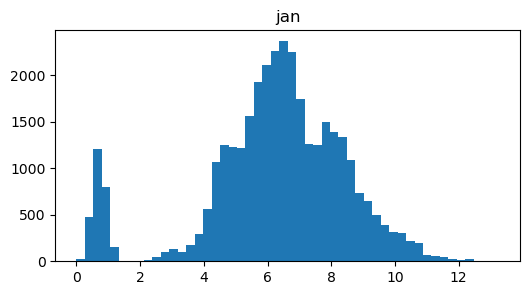

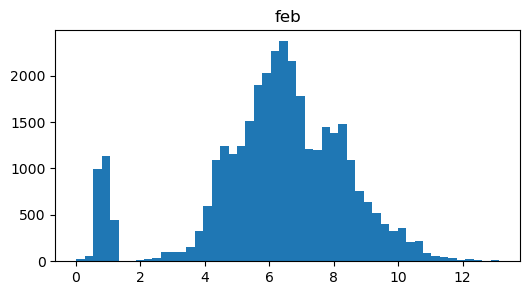

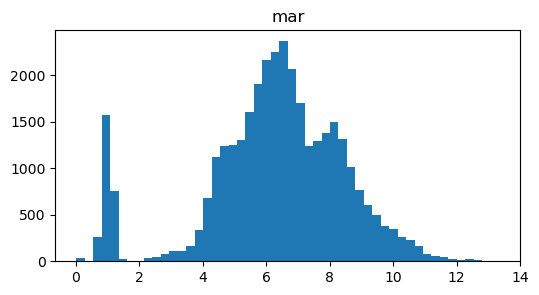

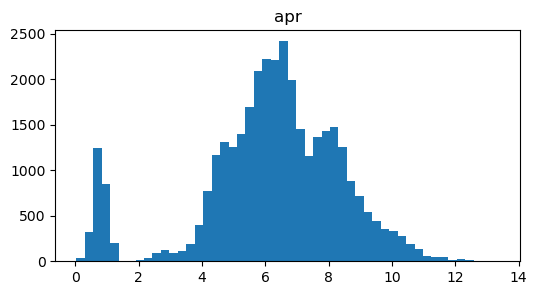

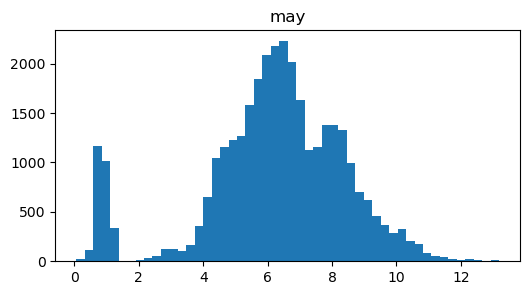

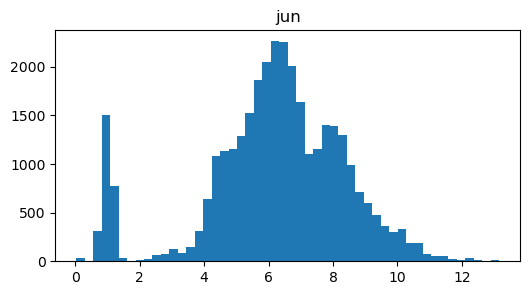

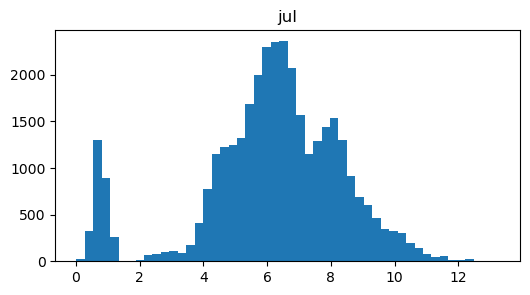

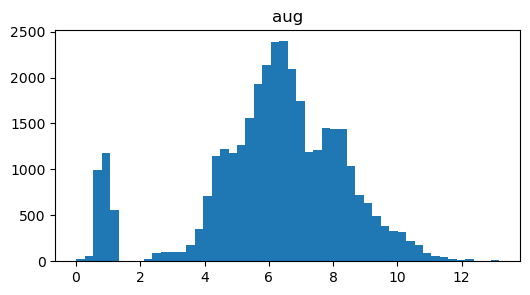

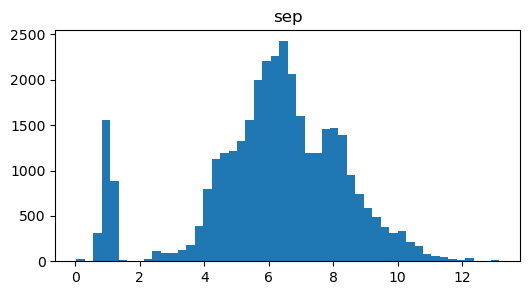

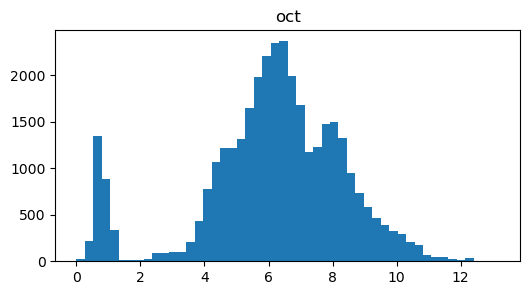

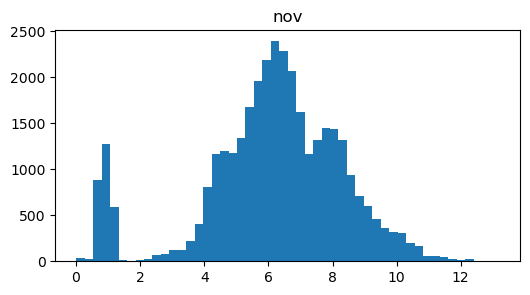

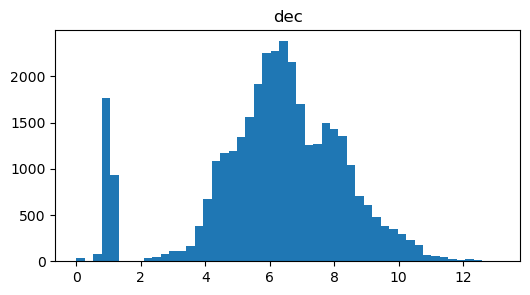

In [43]:
import numpy as np

for month in months:
    plt.figure(figsize=(6,3))

    plt.hist(
        np.log1p(df_clean[month].dropna()),
        bins=50
    )

    plt.title(month)
    plt.show()

In [44]:
for month in months:
    print(month)

    print(
        df_clean[month].quantile(
            [0.90,0.95,0.99,0.999]
        )
    )

    print()

jan
0.900      6503.400
0.950     13675.550
0.990     46377.960
0.999    210801.591
Name: jan, dtype: float64

feb
0.900      6364.00
0.950     13533.00
0.990     45212.92
0.999    222624.61
Name: feb, dtype: float64

mar
0.900      6803.400
0.950     14247.800
0.990     48140.240
0.999    229739.856
Name: mar, dtype: float64

apr
0.900      6383.000
0.950     13462.500
0.990     45802.680
0.999    225476.352
Name: apr, dtype: float64

may
0.900      6312.900
0.950     13210.850
0.990     44738.350
0.999    218228.872
Name: may, dtype: float64

jun
0.900      6132.600
0.950     12884.550
0.990     43280.950
0.999    211964.127
Name: jun, dtype: float64

jul
0.900      6076.800
0.950     12706.150
0.990     43351.890
0.999    216592.337
Name: jul, dtype: float64

aug
0.900      6112.000
0.950     12866.350
0.990     43853.090
0.999    208963.027
Name: aug, dtype: float64

sep
0.900      5920.000
0.950     12443.000
0.990     42300.880
0.999    210442.542
Name: sep, dtype: float64

oct
0

**Interpretation**

Extreme values were investigated through quantile analysis and log-transformed histograms. Although the monthly variables exhibit strong right skewness, the upper-tail observations appear to represent valid national-level aggregates rather than data-entry errors. Consequently, no outlier removal was performed.

<a id='eda'></a>
# 3. Exploratory Data Analysis

### Melting

In [45]:
df_long = df_clean.melt(
    id_vars=["sa","naics_sector","series","geo","year"],
    value_vars=months,
    var_name="month",
    value_name="value"
)


In [46]:
month_map = {
    "jan":1,
    "feb":2,
    "mar":3,
    "apr":4,
    "may":5,
    "jun":6,
    "jul":7,
    "aug":8,
    "sep":9,
    "oct":10,
    "nov":11,
    "dec":12
}

df_long["month_num"] = df_long["month"].map(month_map)

df_long["date"] = pd.to_datetime(
    dict(
        year=df_long["year"],
        month=df_long["month_num"],
        day=1
    )
)

In [47]:
df_long = df_long.drop(columns=["month_num"])

In [48]:
df_long = df_long.sort_values("date")

In [49]:
df_long[["date","value"]].head()

,date,value
35189,2004-01-01,NaN
36325,2004-01-01,NaN
36324,2004-01-01,NaN
36323,2004-01-01,NaN
36322,2004-01-01,NaN


In [50]:
df_long["date"].min(), df_long["date"].max()

(Timestamp('2004-01-01 00:00:00'), Timestamp('2026-12-01 00:00:00'))

In [51]:
df_long["value"].isna().sum()

np.int64(29557)

In [52]:
for month in months:
    print(month)
    print(df_raw[month].dtype)

jan
str
feb
str
mar
str
apr
str
may
str
jun
str
jul
str
aug
str
sep
str
oct
str
nov
str
dec
str


In [53]:
for month in months:
    print(
        month,
        df_clean[month].isna().sum()
    )

jan 2419
feb 2479
mar 2396
apr 2371
may 3619
jun 3739
jul 2031
aug 2051
sep 2115
oct 2095
nov 2123
dec 2119


In [54]:
summary["NA_count"].sum()

np.int64(3392)

In [55]:
df_clean[months].isna().sum().sum()

np.int64(29557)

In [56]:
for month in months:

    bad = (
        df_raw[month]
        .astype(str)
        .loc[lambda x:
             ~x.str.match(
                 r'^-?\d+(\.\d+)?$'
             )
        ]
        .unique()
    )

    print(month, sorted(bad))

jan ['', 'D', 'NA']
feb ['', 'D', 'NA', 'S']
mar ['', 'D', 'NA', 'S']
apr ['', 'D', 'NA']
may ['', 'D', 'NA']
jun ['', 'D', 'NA', 'S']
jul ['', 'D', 'NA', 'S']
aug ['', 'D', 'NA']
sep ['', 'D', 'NA', 'S']
oct ['', 'D', 'NA', 'S']
nov ['', 'D', 'NA']
dec ['', 'D', 'NA']


In [57]:
empty_summary = pd.Series({
    month: (df_raw[month] == "").sum()
    for month in months
})

empty_summary

jan    1694
feb    1694
mar    1694
apr    1694
may    2926
jun    2926
jul    1232
aug    1232
sep    1232
oct    1232
nov    1232
dec    1232
dtype: int64

In [58]:
empty_summary.sum()

np.int64(20020)

### Missing Values and Special Codes

The monthly variables were originally stored as string values and contained both numeric observations and special codes.

The following special values were identified:

Code -	Description
- D:	Estimate withheld to avoid disclosing individual establishments
- S:	Estimate does not meet publication standards
- NA:	Not available
- "" (blank):	Missing value in the source dataset

In [59]:
(
    df_long
    .groupby("series")["value"]
    .apply(lambda x: x.isna().sum())
    .sort_values(ascending=False)
)

series
BF_SBF8Q    5736
BF_BF8Q     4388
BF_SBF4Q    2696
BF_PBF4Q    2692
BF_PBF8Q    2692
BA_BA       2156
BA_CBA      2156
BA_HBA      2156
BA_WBA      2156
BF_BF4Q     1372
BF_DUR4Q     685
BF_DUR8Q     672
Name: value, dtype: int64

### Missing values after cleaning

After converting monthly variables to numeric format, ~30000 observations became missing (NaN).

The missing values are not randomly distributed. They are concentrated in specific Business Formation (BF) series, particularly:

- BF_SBF8Q
- BF_BF8Q
- BF_SBF4Q
- BF_PBF4Q
- BF_PBF8Q

Some BF series also have shorter temporal coverage (ending in 2021–2022 rather than extending through 2026), which contributes to the higher number of missing observations.

In [60]:
df_long.shape

(442596, 8)

In [61]:
df_long.info()

<class 'pandas.DataFrame'>
Index: 442596 entries, 35189 to 406634
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   sa            442596 non-null  str           
 1   naics_sector  442596 non-null  str           
 2   series        442596 non-null  str           
 3   geo           442596 non-null  str           
 4   year          442596 non-null  int64         
 5   month         442596 non-null  str           
 6   value         413039 non-null  float64       
 7   date          442596 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 30.4 MB


To facilitate time-series analysis, the dataset was transformed from a wide format (one column per month) into a long format using pandas.melt().

The resulting dataset contains: 442,596 observations, 8 variables

A new datetime variable (date) was created by combining the year and month information.

The final structure includes:

- Geographic area (geo)
- Industry sector (naics_sector)
- Business formation series (series)
- Seasonal adjustment indicator (sa)
- Calendar year (year)
- Month (month)
- Observation value (value)
- Date (date)

## 3.1 Trend Analysis

### This section addresses Research Question 1:
### How have business applications evolved over time in the United States?

In [62]:
df_long["series"].value_counts()

series
BA_BA       42504
BF_PBF8Q    42504
BF_PBF4Q    42504
BF_SBF4Q    42504
BF_SBF8Q    42504
BA_CBA      42504
BA_HBA      42504
BA_WBA      42504
BF_BF4Q     35112
BF_BF8Q     33264
BF_DUR4Q    17556
BF_DUR8Q    16632
Name: count, dtype: int64

### Series meaning
- BA_BA	Business Applications
- BA_CBA	High Propensity Business Applications
- BA_HBA	Business Applications from Corporations
- BA_WBA	Business Applications with Planned Wages
- BF_BF4Q	Business Formations within 4 Quarters
- BF_BF8Q	Business Formations within 8 Quarters
- BF_DUR4Q	Formation Rate within 4 Quarters
- BF_DUR8Q	Formation Rate within 8 Quarters
- BF_PBF4Q	Projected Business Formations 4Q
- BF_PBF8Q	Projected Business Formations 8Q
- BF_SBF4Q	Spliced Business Formations 4Q
- BF_SBF8Q	Spliced Business Formations 8Q

### Business Applications Over Time 

BA_BA
- longest serie
- few missing values
- easy to interpret
- main variable on BFS studios

In [63]:
us_ba = df_long[
    (df_long["geo"] == "US") &
    (df_long["series"] == "BA_BA")
].copy()

us_ba.head()
us_ba.shape

(11592, 8)

In [64]:
df_analysis = df_long.dropna(subset=["value"])

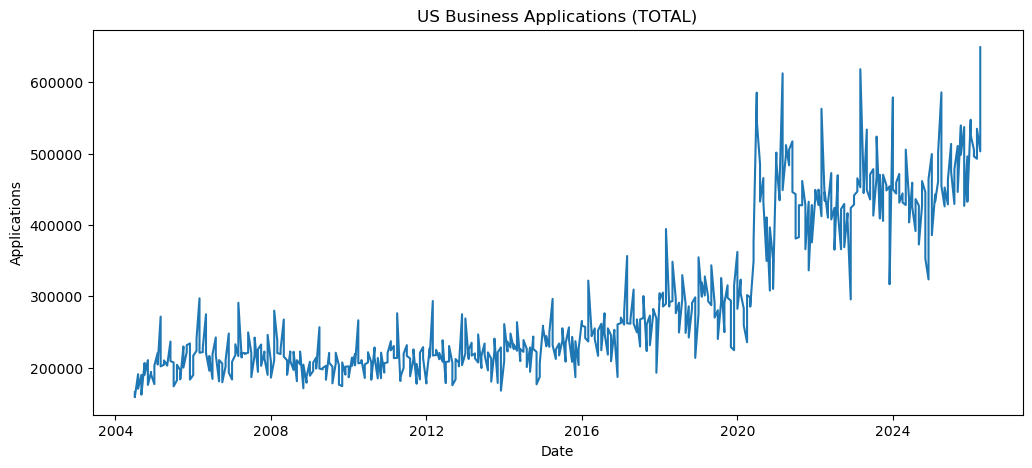

In [65]:
us_ba_total = df_analysis[
    (df_analysis["geo"] == "US") &
    (df_analysis["series"] == "BA_BA") &
    (df_analysis["naics_sector"] == "TOTAL")
].copy()

us_ba_total.shape
us_ba_total.head()
plt.figure(figsize=(12,5))

plt.plot(
    us_ba_total["date"],
    us_ba_total["value"]
)

plt.title("US Business Applications (TOTAL)")
plt.xlabel("Date")
plt.ylabel("Applications")
plt.show()

In [66]:
us_ba_total.shape
us_ba_total.head()
us_ba_total["date"].min(), us_ba_total["date"].max()
us_ba_total["sa"].value_counts()

sa
U    262
A    262
Name: count, dtype: int64

In datasets Census/BFS:

U = Unadjusted
A = Seasonally Adjusted

Mixing of both series in same graph

### Selection of the Adjusted Series

In [67]:
us_ba_adj = us_ba_total[
    us_ba_total["sa"] == "A"
].copy()

us_ba_adj.shape

(262, 8)

In [68]:
us_ba_unadj = us_ba_total[
    us_ba_total["sa"] == "U"
].copy()

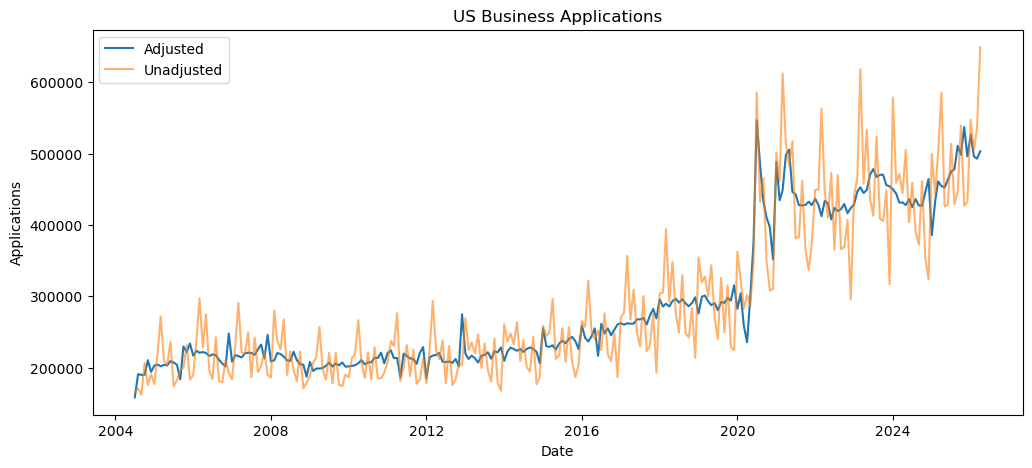

In [69]:
plt.figure(figsize=(12,5))

plt.plot(
    us_ba_adj["date"],
    us_ba_adj["value"],
    label="Adjusted"
)

plt.plot(
    us_ba_unadj["date"],
    us_ba_unadj["value"],
    label="Unadjusted",
    alpha=0.6
)

plt.legend()
plt.title("US Business Applications")
plt.xlabel("Date")
plt.ylabel("Applications")
plt.show()


### Adjusted series vs unadjusted


Blue (Adjusted): softer curve
Orange (Unadjusted): remarckably annual cycles 

sa = A
A is fixed for stations


### Distribution of Applications

In [70]:
us_ba_adj.describe()

,year,value,date
count,262.000000,262.000000,262
mean,2014.916031,290336.637405,2015-05-17 09:59:05.038168
min,2004.000000,158475.000000,2004-07-01 00:00:00
25%,2009.250000,213153.500000,2009-12-08 18:00:00
50%,2015.000000,234892.500000,2015-05-16 12:00:00
75%,2020.000000,409865.000000,2020-10-24 06:00:00
max,2026.000000,546719.000000,2026-04-01 00:00:00
std,6.327024,102450.024033,NaN


<Axes: ylabel='Frequency'>

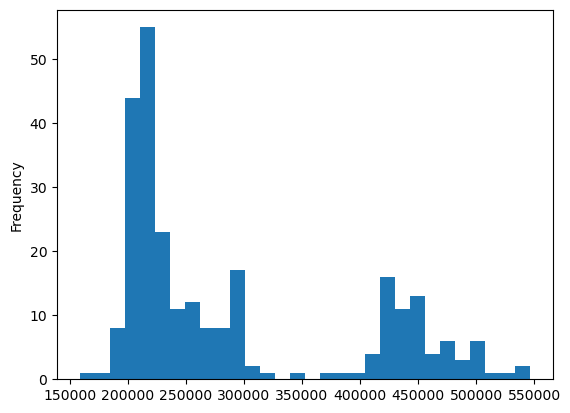

In [71]:
us_ba_adj["value"].plot(kind="hist", bins=30)

### Interpretation

The time series reveals three distinct periods. Business applications remained relatively stable between 2004 and 2015, followed by moderate growth through 2020. A sharp increase occurred during 2020–2021, after which application volumes stabilized at a substantially higher level than in previous years.

The histogram supports this observation by showing a bimodal distribution, with one concentration of observations between approximately 190,000–300,000 applications and another between 400,000–550,000 applications. The gap between these ranges suggests the presence of two distinct historical regimes.

Descriptive statistics reinforce this interpretation. The mean number of applications (290,337) exceeds the median (234,892), indicating a right-skewed distribution driven by the exceptionally high application volumes observed in recent years.

### Average Applications by Year

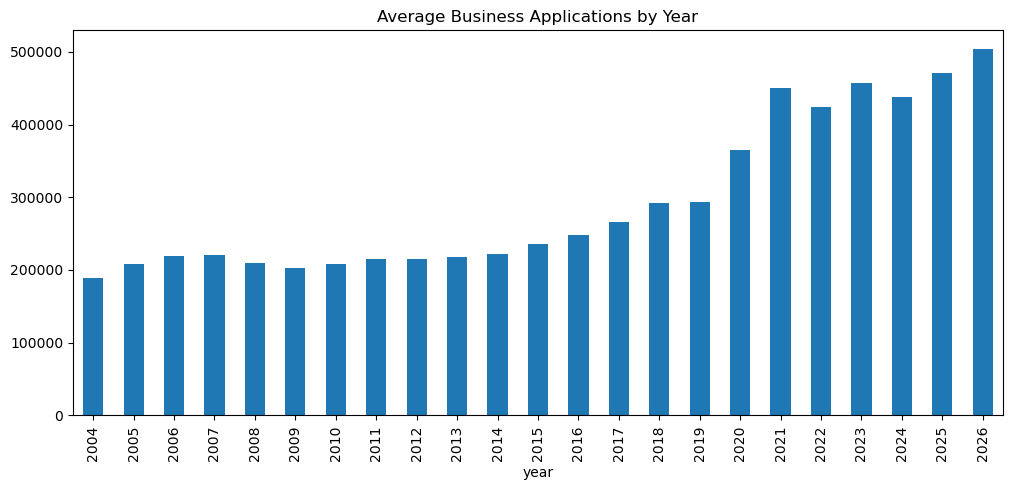

In [72]:
annual = (
    us_ba_adj
    .groupby("year")["value"]
    .mean()
)

annual.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Average Business Applications by Year")
plt.show()

### Interpretation

The annual averages reinforce the pattern observed in the monthly series. Business applications grew gradually before 2020 and increased sharply during 2020–2021. Since then, application volumes have remained at a substantially higher level, suggesting a persistent structural shift in business formation activity.

### Average Applications by Month

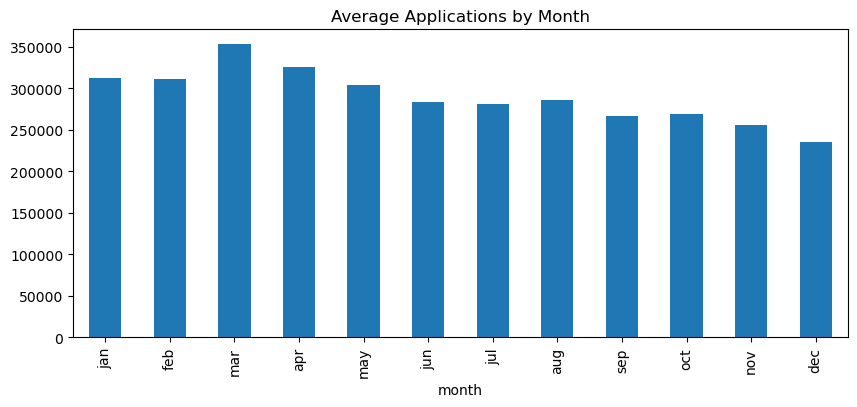

In [73]:
monthly = (
    us_ba_unadj
    .groupby("month")["value"]
    .mean()
    .reindex(months)
)

monthly.plot(
    kind="bar",
    figsize=(10,4)
)

plt.title("Average Applications by Month")
plt.show()

### Seasonally Adjusted vs Unadjusted Series

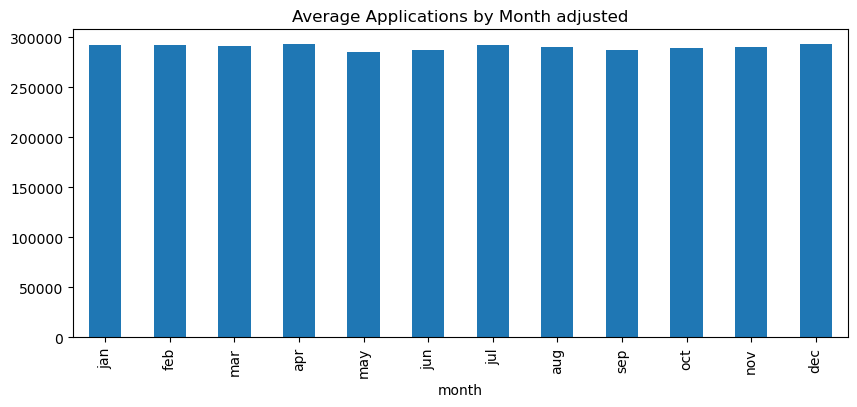

In [74]:
monthly = (
    us_ba_adj
    .groupby("month")["value"]
    .mean()
    .reindex(months)
)

monthly.plot(
    kind="bar",
    figsize=(10,4)
)

plt.title("Average Applications by Month adjusted")
plt.show()

### Interpretation

The monthly averages reveal a clear seasonal pattern in the original business application series. Application volumes tend to be highest during the first months of the year, particularly in March and April, and gradually decline toward the end of the year, with November and December exhibiting the lowest levels.

However, these differences largely disappear after seasonal adjustment. The adjusted series shows relatively stable application volumes across months, indicating that the observed monthly fluctuations in the original data are primarily driven by seasonal effects rather than changes in the underlying level of business formation activity.

This finding supports the use of the seasonally adjusted series for the remainder of the analysis, as it provides a clearer view of long-term trends and structural changes.


## 3.2. Growth Analysis

### Research Question 4:
How did business application patterns change before and after COVID-19?

### Rolling Average Analysis

A 12-month rolling average was used to smooth short-term fluctuations and highlight the underlying trend in business applications.



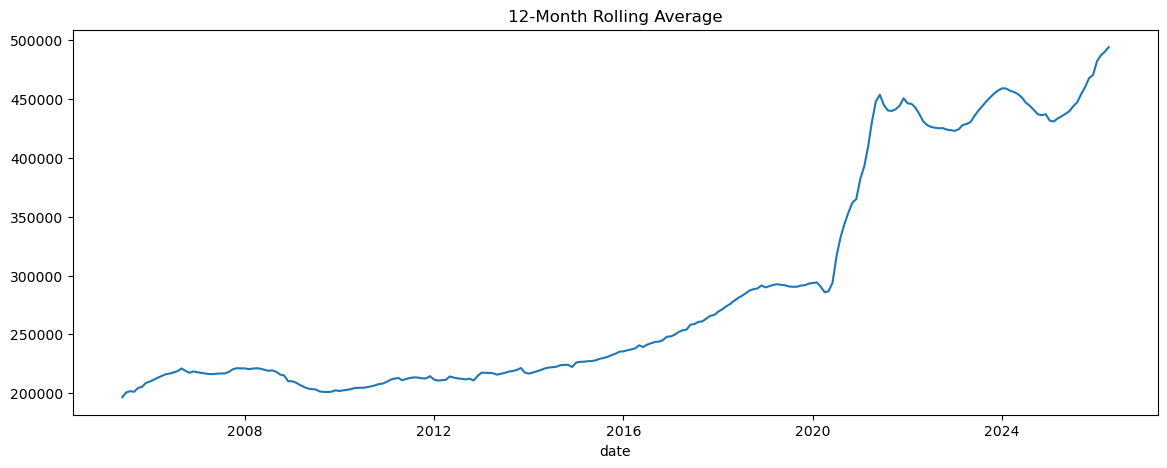

In [75]:
plt.figure(figsize=(14,5))

plt.plot(
    us_ba_adj["date"],
    us_ba_adj["value"].rolling(12).mean()
)

plt.title("12-Month Rolling Average")
plt.xlabel('date')
plt.show()

### Interpretation

The 12-month rolling average provides the clearest view of the long-term trend in business applications. Between 2004 and 2014, application volumes remained relatively stable, fluctuating around 200,000–220,000 applications per month. From 2015 to 2019, a gradual upward trend emerged, with average volumes increasing to nearly 290,000 applications.

A pronounced shift occurred during 2020–2021, when the rolling average rose rapidly from approximately 290,000 to more than 450,000 applications. Most importantly, application volumes did not return to their pre-pandemic levels after this increase. Instead, they stabilized at a substantially higher range, suggesting that the rise in business formation activity reflects a persistent structural change rather than a temporary shock.


### Annual Growth Rate of Business Applications

To better understand how business applications evolved over time, we first calculated the average number of applications for each year.

The annual growth rate was then computed as the percentage change relative to the previous year:

$$
Growth\ Rate = \frac{Current\ Year - Previous\ Year}{Previous\ Year} \times 100
$$

This metric allows us to identify periods of acceleration and slowdown in entrepreneurial activity and highlights years in which business formation experienced unusually strong growth.


In [76]:
annual = (
    us_ba_adj
    .groupby("year")["value"]
    .mean()
)

annual_growth = annual.pct_change() * 100
annual_growth.describe()

count    22.000000
mean      4.831361
std       7.784541
min      -6.008707
25%       0.702766
50%       3.841852
75%       7.563892
max      24.511152
Name: value, dtype: float64

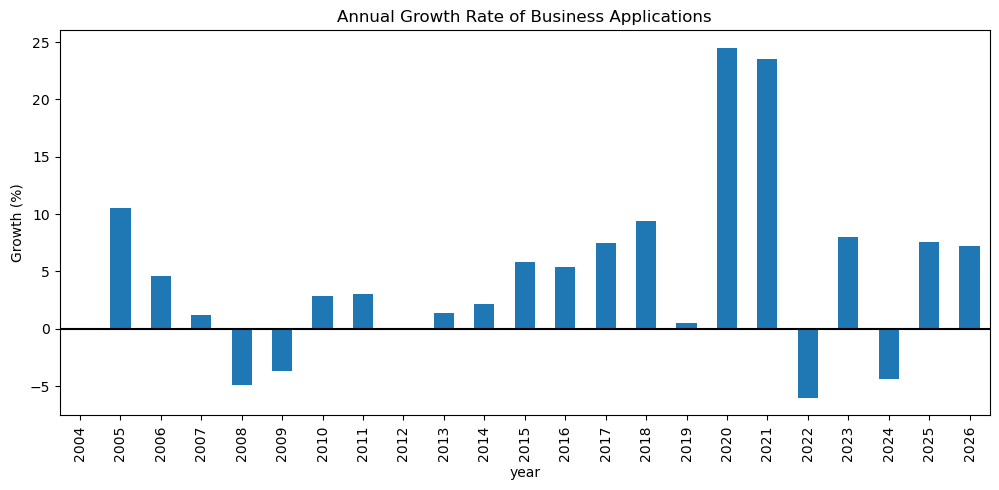

In [77]:
plt.figure(figsize=(12,5))

annual_growth.plot(kind="bar")

plt.axhline(0, color="black")
plt.title("Annual Growth Rate of Business Applications")
plt.ylabel("Growth (%)")

plt.show()

### Growth Comparison Across Periods

### Growth Patterns Before and After COVID-19

To better understand long-term changes in business formation activity, annual growth rates were analyzed across three distinct periods.




#### 2005–2014: Slow Growth Period

Business applications grew at an average annual rate of approximately **1.7%** during this period. Growth was generally modest, with temporary declines associated with the 2008–2009 financial crisis followed by a gradual recovery.



#### 2015–2019: Accelerated Expansion

Between 2015 and 2019, annual growth increased to an average of **5.7%**, indicating a stronger expansion in entrepreneurial activity. Several consecutive years experienced growth rates above 5%, suggesting a shift toward a more dynamic business environment.



#### 2020–2021: COVID-19 Surge

The most significant change in the entire dataset occurred during the COVID-19 period. Business applications increased by **24.5% in 2020** and **23.5% in 2021**, far exceeding historical growth rates.

This surge coincided with major economic and social changes, including increased remote work, accelerated digitalization, growth in e-commerce, and higher levels of self-employment. Together, these factors may have encouraged new business creation across multiple sectors.



#### Post-Pandemic Period (2022–2026)

Although growth moderated after 2021, business application volumes remained substantially above pre-pandemic levels. Average growth during 2023–2026 remained positive and considerably higher than that observed during 2005–2014.



### Key Finding

The most important result is not simply that business applications increased over time, but that the COVID-19 period appears to have produced a lasting upward shift in entrepreneurial activity.

Multiple analyses support this conclusion, including:

* Long-term time series trends
* Seasonally adjusted and unadjusted comparisons
* 12-month moving averages
* Annual averages
* Annual growth rates
* Pre- and post-COVID comparisons

The data suggest that business formation activity did not return to its pre-2020 baseline, indicating a potential structural change in the level of business applications in the United States.

### Interpretation

Most years prior to 2020 exhibited relatively modest growth rates, generally below 10%. However, the onset of the COVID-19 period produced an exceptional increase:

- **2020:** +24.5%
- **2021:** +23.5%

These were the two highest annual growth rates observed in the dataset.

Although growth moderated after 2021, application volumes remained substantially above their pre-pandemic levels. This suggests that the COVID-19 period coincided with a major expansion in business formation activity and may have contributed to a lasting structural shift in entrepreneurial behavior.

In [78]:
pre_2015 = annual_growth.loc[2005:2014].mean()
pre_covid = annual_growth.loc[2015:2019].mean()
post_covid = annual_growth.loc[2023:2026].mean()

print(pre_2015)
print(pre_covid)
print(post_covid)

1.7190416893829727
5.739428783236926
4.60151479881723


## 3.3 Sector Analysis

### Research Question 2
Which sectors receive the most business applications?

In [79]:
df_analysis["naics_sector"].value_counts()

naics_sector
TOTAL       304608
NAICS81       5488
NAICS72       5488
NAICS71       5488
NAICS62       5488
NAICS61       5488
NAICS56       5488
NAICS54       5488
NAICSMNF      5488
NAICS23       5488
NAICS42       5488
NAICSRET      5488
NAICSTW       5488
NAICS51       5488
NAICS53       5488
NAICS52       5488
NAICS21       5476
NAICS11       5428
NAICS55       5139
NONAICS       5052
NAICS22       5016
Name: count, dtype: int64

In [80]:
sorted(df_analysis["naics_sector"].unique())

['NAICS11',
 'NAICS21',
 'NAICS22',
 'NAICS23',
 'NAICS42',
 'NAICS51',
 'NAICS52',
 'NAICS53',
 'NAICS54',
 'NAICS55',
 'NAICS56',
 'NAICS61',
 'NAICS62',
 'NAICS71',
 'NAICS72',
 'NAICS81',
 'NAICSMNF',
 'NAICSRET',
 'NAICSTW',
 'NONAICS',
 'TOTAL']

#### Top Sector by Application Volume

In [81]:
sector_data = df_analysis[
    (df_analysis["geo"] == "US") &
    (df_analysis["series"] == "BA_BA") &
    (df_analysis["sa"] == "A") &
    (df_analysis["naics_sector"] != "TOTAL")
].copy()

sector_data.shape

(5240, 8)

In [82]:
sector_mean = (
    sector_data
    .groupby("naics_sector")["value"]
    .mean()
    .sort_values(ascending=False)
)

sector_mean

naics_sector
NAICSRET    45351.748092
NAICS54     38399.534351
NAICS23     29740.729008
NAICS81     26670.286260
NAICS56     20338.667939
NAICSTW     18842.816794
NAICS62     18354.358779
NAICS53     16943.713740
NAICS72     15675.450382
NAICS52     14032.267176
NAICS71      9535.232824
NAICS42      8908.286260
NAICS51      6076.935115
NAICSMNF     5753.175573
NAICS61      4635.438931
NONAICS      4369.832061
NAICS11      3545.526718
NAICS55      2233.675573
NAICS21       609.843511
NAICS22       319.083969
Name: value, dtype: float64

**Interpretation**

Retail Trade (NAICSRET), Professional Services (NAICS54), and Construction (NAICS23) consistently received the highest average number of business applications between 2004 and 2026. This suggests that business formation activity is concentrated in a small number of sectors, with retail and professional services accounting for a particularly large share of total applications.

#### Evolution of Leading Sectors Over Time

In [83]:
top_sectors = (
     sector_mean
    .head(10)
    .index
)

top_sectors

Index(['NAICSRET', 'NAICS54', 'NAICS23', 'NAICS81', 'NAICS56', 'NAICSTW',
       'NAICS62', 'NAICS53', 'NAICS72', 'NAICS52'],
      dtype='str', name='naics_sector')

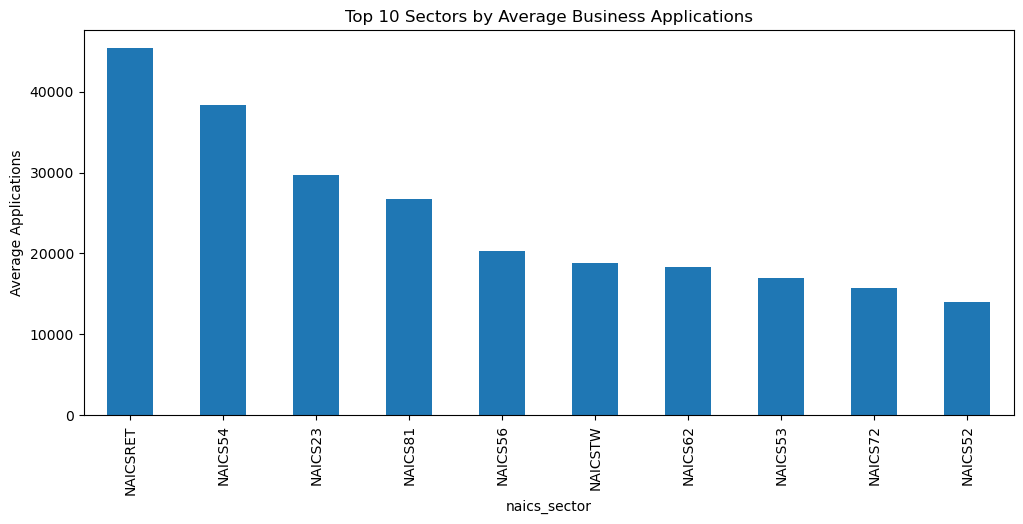

In [84]:
sector_mean.head(10).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 10 Sectors by Average Business Applications")
plt.ylabel("Average Applications")
plt.show()

### Interpretation

Retail Trade (NAICSRET), Professional Services (NAICS54), and Construction (NAICS23) consistently received the highest average number of business applications between 2004 and 2026.

### Growth by Sector

To evaluate sector performance after COVID-19, average annual applications were calculated for two periods:

- Pre-COVID (2015–2019)
- Post-COVID (2023–2026)

Growth was then computed as:

Growth (%) =
(Post-COVID Mean − Pre-COVID Mean)
/ Pre-COVID Mean × 100

In [85]:
sector_annual = (
    sector_data
    .groupby(["naics_sector", "year"])["value"]
    .mean()
    .reset_index()
)


In [86]:
sector_pre_covid = sector_annual[
    sector_annual["year"].between(2015, 2019)
]

sector_post_covid = sector_annual[
    sector_annual["year"].between(2023, 2026)
]

### Research Question 3
Which sectors experienced the largest post-COVID growth?

####  Pre- and Post-COVID Sector Averages

In [87]:
pre_mean = (
    sector_pre_covid
    .groupby("naics_sector")["value"]
    .mean()
)

post_mean = (
    sector_post_covid
    .groupby("naics_sector")["value"]
    .mean()
)

In [88]:
sector_growth = pd.DataFrame({
    "pre_covid": pre_mean,
    "post_covid": post_mean
})

sector_growth.head()

,pre_covid,post_covid
naics_sector,,
NAICS11,3418.933333,5018.583333
NAICS21,543.166667,508.250000
NAICS22,248.750000,644.791667
NAICS23,28207.183333,44755.833333
NAICS42,8339.483333,10039.000000


#### Sector Growth Rates

In [89]:
sector_growth["growth_pct"] = (
    (
        sector_growth["post_covid"]
        - sector_growth["pre_covid"]
    )
    / sector_growth["pre_covid"]
) * 100

In [90]:
sector_growth = sector_growth.sort_values(
    "growth_pct",
    ascending=False
)

sector_growth

,pre_covid,post_covid,growth_pct
naics_sector,,,
NONAICS,2713.850000,11675.500000,330.219061
NAICS55,1877.966667,5227.750000,178.372886
NAICS22,248.750000,644.791667,159.212730
NAICSRET,37441.350000,85932.062500,129.511122
NAICS56,18133.283333,33190.125000,83.034282
NAICSTW,17551.650000,31615.041667,80.125753
NAICS72,14279.033333,25177.395833,76.324232
NAICS54,35849.283333,62846.750000,75.308247
NAICS81,24285.183333,41602.375000,71.307642


#### Sectors with the Highest Growth

In [91]:
sector_growth.head(10)

,pre_covid,post_covid,growth_pct
naics_sector,,,
NONAICS,2713.850000,11675.500000,330.219061
NAICS55,1877.966667,5227.750000,178.372886
NAICS22,248.750000,644.791667,159.212730
NAICSRET,37441.350000,85932.062500,129.511122
NAICS56,18133.283333,33190.125000,83.034282
NAICSTW,17551.650000,31615.041667,80.125753
NAICS72,14279.033333,25177.395833,76.324232
NAICS54,35849.283333,62846.750000,75.308247
NAICS81,24285.183333,41602.375000,71.307642


#### Sectors with the Lowest Growth

In [92]:
sector_growth.tail(10)

,pre_covid,post_covid,growth_pct
naics_sector,,,
NAICS51,5732.450000,9325.291667,62.675499
NAICS61,4513.133333,7240.208333,60.425314
NAICS23,28207.183333,44755.833333,58.668212
NAICS11,3418.933333,5018.583333,46.787985
NAICS71,9454.800000,13495.187500,42.733717
NAICSMNF,5427.250000,7522.020833,38.597279
NAICS53,17347.850000,23608.833333,36.090832
NAICS52,14123.783333,18899.791667,33.815361
NAICS42,8339.483333,10039.000000,20.379160


#### Absolute vs Percentage Growth

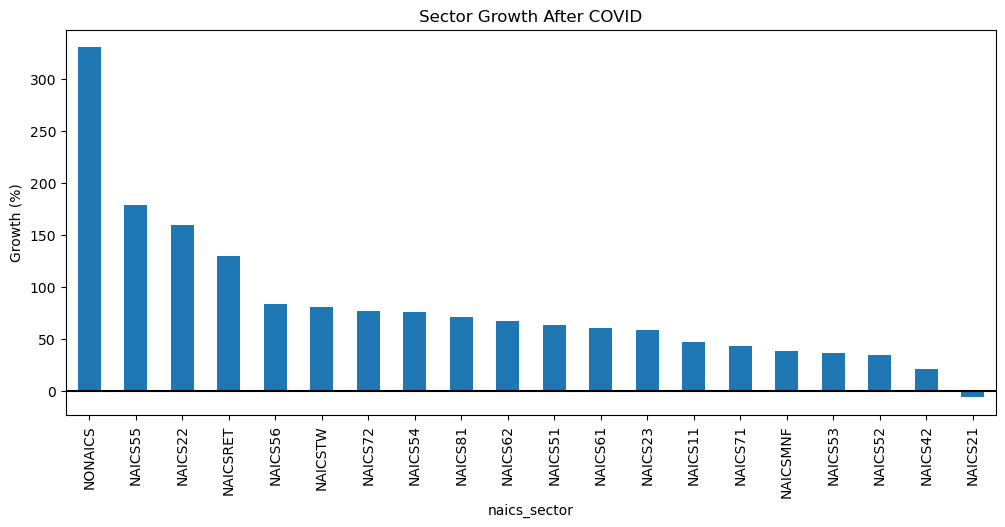

In [93]:
plt.figure(figsize=(12,5))

sector_growth["growth_pct"].plot(
    kind="bar"
)

plt.axhline(0, color="black")
plt.title("Sector Growth After COVID")
plt.ylabel("Growth (%)")

plt.show()

In [94]:
sector_growth["absolute_change"] = (
    sector_growth["post_covid"]
    - sector_growth["pre_covid"]
)

sector_growth.sort_values(
    "absolute_change",
    ascending=False
).head(10)

,pre_covid,post_covid,growth_pct,absolute_change
naics_sector,,,,
NAICSRET,37441.350000,85932.062500,129.511122,48490.712500
NAICS54,35849.283333,62846.750000,75.308247,26997.466667
NAICS81,24285.183333,41602.375000,71.307642,17317.191667
NAICS23,28207.183333,44755.833333,58.668212,16548.650000
NAICS56,18133.283333,33190.125000,83.034282,15056.841667
NAICSTW,17551.650000,31615.041667,80.125753,14063.391667
NAICS62,17382.333333,29092.333333,67.367250,11710.000000
NAICS72,14279.033333,25177.395833,76.324232,10898.362500
NONAICS,2713.850000,11675.500000,330.219061,8961.650000


**Interpretation** 

Although NONAICS experienced the highest percentage growth after COVID-19 (330%), its absolute increase was approximately 9,000 applications. In contrast, Retail (NAICSRET) grew by 129% but added nearly 48,500 applications, making it the largest contributor to the increase in business formation.

#### Does the Choice of Growth Metric Matter?

The choice of growth metric has a substantial impact on sector rankings.

When growth is measured as a percentage change, NONAICS appears to be the fastest-growing sector after COVID-19 (+330%). However, this result is largely driven by its relatively small pre-pandemic baseline.

When growth is measured using the absolute increase in applications, Retail Trade (NAICSRET) and Professional Services (NAICS54) emerge as the largest contributors to the overall rise in business applications.

These results suggest that percentage growth is useful for identifying sectors with strong relative expansion, while absolute growth provides a better measure of each sector's contribution to total business formation activity.

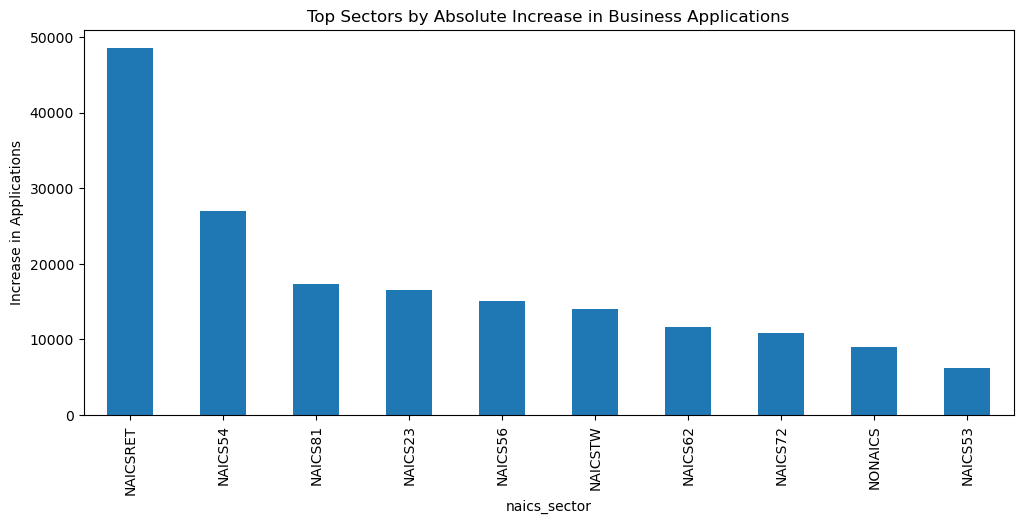

In [95]:
sector_growth.sort_values(
    "absolute_change",
    ascending=False
)["absolute_change"].head(10).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top Sectors by Absolute Increase in Business Applications")
plt.ylabel("Increase in Applications")
plt.show()

### Interpretation

Retail Trade (NAICSRET) and Professional Services (NAICS54) generated the largest absolute increases in business applications after COVID-19. While NONAICS showed the highest percentage growth, its contribution in terms of additional applications was considerably smaller. This highlights the importance of evaluating both percentage and absolute growth when comparing sectors.

### Research Question 3 Part 2:
Which sectors experienced the largest post-COVID growth?

#### Evolution of the Top Five Sectors

In [98]:
top5 = [
    "NAICSRET",
    "NAICS54",
    "NAICS23",
    "NAICS81",
    "NAICS56"
]

In [102]:
top5_data = sector_data[
    sector_data["naics_sector"].isin(top5)
].copy()

top5_data.head()

,sa,naics_sector,series,geo,year,month,value,date
256512,A,NAICS23,BA_BA,US,2004,jul,21193.0,2004-07-01
256527,A,NAICS81,BA_BA,US,2004,jul,12723.0,2004-07-01
256522,A,NAICS56,BA_BA,US,2004,jul,10870.0,2004-07-01
256520,A,NAICS54,BA_BA,US,2004,jul,19764.0,2004-07-01
256515,A,NAICSRET,BA_BA,US,2004,jul,20082.0,2004-07-01


In [104]:
top5_annual = (
    top5_data
    .groupby(["year", "naics_sector"])["value"]
    .mean()
    .reset_index()
)

top5_annual.head()

,year,naics_sector,value
0,2004,NAICS23,25733.833333
1,2004,NAICS54,23374.500000
2,2004,NAICS56,12536.833333
3,2004,NAICS81,15830.166667
4,2004,NAICSRET,23602.166667


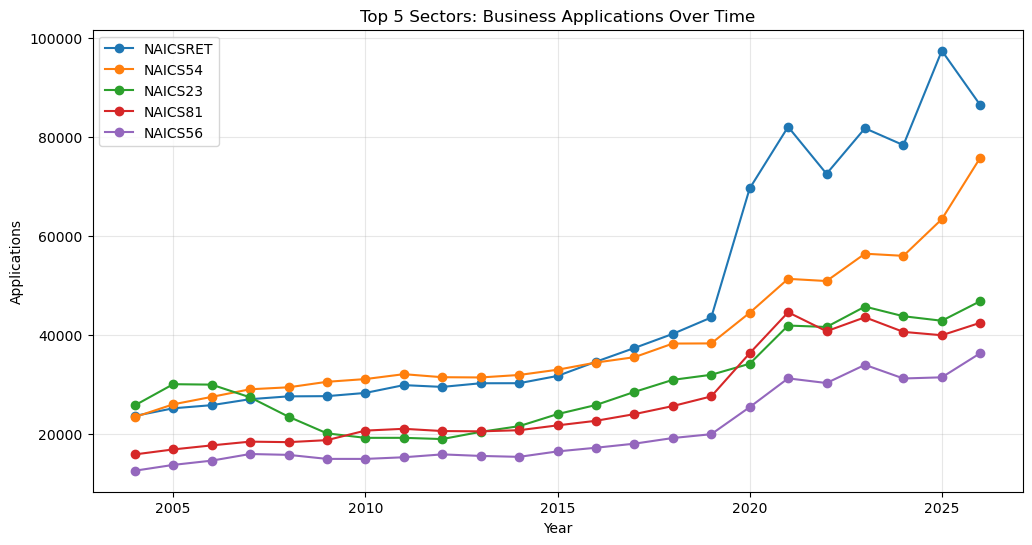

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for sector in top5:
    
    temp = top5_annual[
        top5_annual["naics_sector"] == sector
    ]
    
    plt.plot(
        temp["year"],
        temp["value"],
        marker="o",
        label=sector
    )

plt.title("Top 5 Sectors: Business Applications Over Time")
plt.ylabel("Applications")
plt.xlabel("Year")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Interpretation

All five leading sectors experienced substantial growth after 2020. Retail Trade (NAICSRET) and Professional Services (NAICS54) recorded the largest application volumes throughout the study period and contributed a significant share of the post-pandemic increase.

Construction (NAICS23), Other Services (NAICS81), and Administrative and Support Services (NAICS56) also exhibited sustained growth, although at lower overall volumes.

Overall, the rise in business applications after COVID-19 was broad-based rather than concentrated in a single sector.


<a id='findings'></a>
# 4. Findings 

## Finding 1: 
Business applications increased substantially over time and remained elevated after the COVID-19 period.

## Finding 2: 
Retail Trade and Professional Services consistently generated the largest volumes of business applications.

## Finding 3: 
The COVID-19 period coincided with a major increase in entrepreneurial activity.

## Finding 4: 
Sector rankings differ depending on whether growth is measured using percentage or absolute change.

<a id='limitations'></a>
# 5. Limitations

Several limitations should be considered when interpreting the results of this analysis.

### 1. The analysis does not establish causality

This study identifies trends and associations in business application activity but does not establish causal relationships. Although business applications increased substantially during and after the COVID-19 period, the analysis cannot determine whether the pandemic itself caused this increase.

### 2. Business applications are not equivalent to business creation

The dataset measures business applications rather than successfully established businesses. In addition, it does not provide information on application approvals, business openings, closures, or long-term survival. Therefore, increases in application volumes should not be interpreted as direct evidence of increases in active business formation.

### 3. Sector-level aggregation may conceal important differences

Industry categories are reported at a relatively high level of aggregation. For example, the Professional, Scientific, and Technical Services sector (NAICS54) includes software development, consulting, engineering, and scientific research activities. Consequently, it is not possible to identify which specific subsectors were primarily responsible for the observed growth.

### 4. The analysis is conducted at the national level

This study focuses exclusively on observations where `geo = "US"`. As a result, the findings describe national business formation trends and should not be interpreted as representative of all states or regions. Considerable geographic variation may exist within the United States.


<a id='conclusions'></a>
# 6. Conclusions

This analysis examined trends in business applications in the United States using the Business Formation Statistics (BFS) dataset.

The results indicate that business applications increased substantially over the study period, with a particularly strong expansion during and after the COVID-19 pandemic. While growth varied across sectors, Retail Trade and Professional Services consistently accounted for a large share of business formation activity. Sector-level analyses also showed that conclusions may differ depending on whether growth is evaluated using percentage changes or absolute increases.

Overall, the evidence suggests that entrepreneurial activity in the United States shifted to a higher level after 2020 and has remained elevated relative to historical trends. Future analyses could explore state-level differences, subsector dynamics, and the relationship between business applications and actual business formation outcomes.


# 7. Forecasting Future Business Applications (Extension)

This section is exploratory and extends the descriptive analysis by fitting a simple linear trend model to historical business application data.

## Annual Dataset for training LinearRegression Model

In [112]:
annual = (
    us_ba_adj
    .groupby("year")["value"]
    .mean()
    .reset_index()
)

annual.head()

,year,value
0,2004,188874.500000
1,2005,208749.666667
2,2006,218450.916667
3,2007,221032.666667
4,2008,210144.750000


## Build Training Dataset

In [114]:
from sklearn.linear_model import LinearRegression

X = annual[["year"]]
y = annual["value"]

## Build and train Model

In [115]:
model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Make predictions on training 

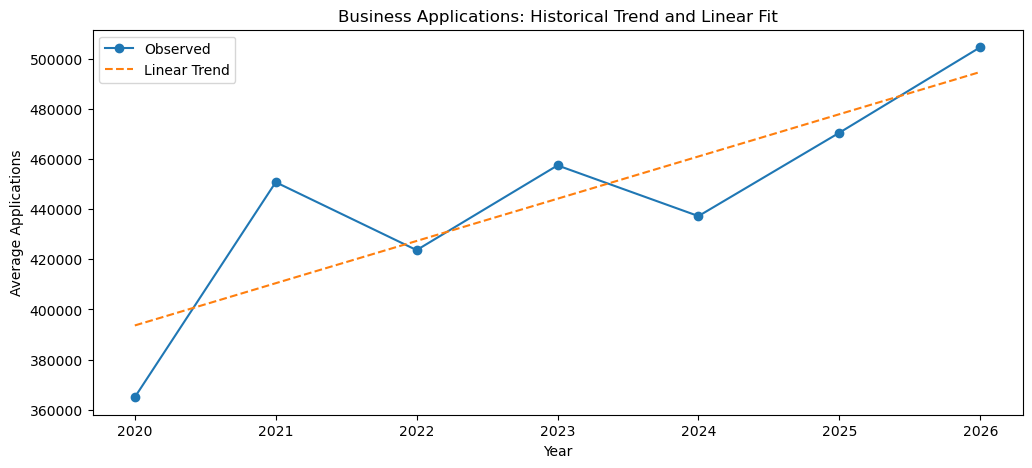

In [116]:
annual["prediction"] = model.predict(X)

plt.figure(figsize=(12,5))

plt.plot(
    annual["year"],
    annual["value"],
    marker="o",
    label="Observed"
)

plt.plot(
    annual["year"],
    annual["prediction"],
    linestyle="--",
    label="Linear Trend"
)

plt.title("Business Applications: Historical Trend and Linear Fit")
plt.xlabel("Year")
plt.ylabel("Average Applications")
plt.legend()

plt.show()

## Make future predictions for 2027-2030 period

In [117]:
future_years = pd.DataFrame({
    "year":[2027,2028,2029,2030]
})

future_years["forecast"] = model.predict(future_years)

future_years

,year,forecast
0,2027,511541.035714
1,2028,528389.202381
2,2029,545237.369048
3,2030,562085.535714


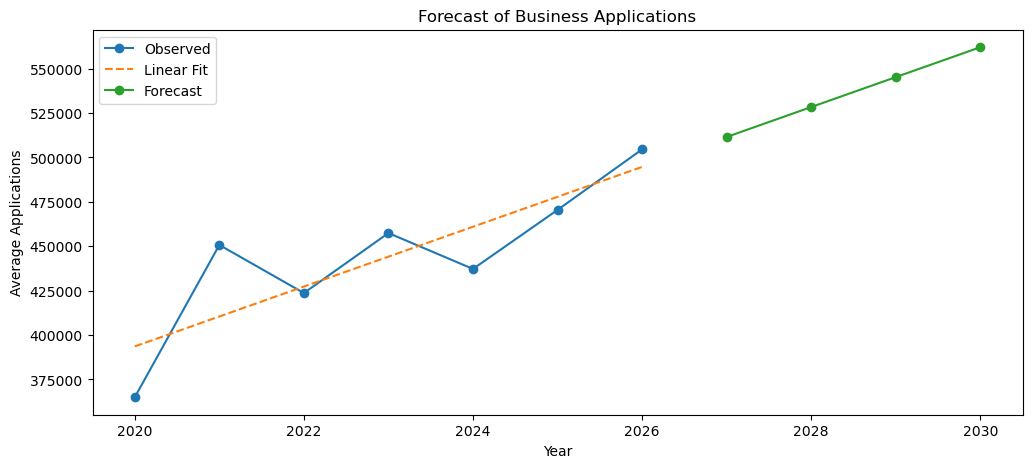

In [118]:
plt.figure(figsize=(12,5))

plt.plot(
    annual["year"],
    annual["value"],
    marker="o",
    label="Observed"
)

plt.plot(
    annual["year"],
    annual["prediction"],
    linestyle="--",
    label="Linear Fit"
)

plt.plot(
    future_years["year"],
    future_years["forecast"],
    marker="o",
    label="Forecast"
)

plt.title("Forecast of Business Applications")
plt.xlabel("Year")
plt.ylabel("Average Applications")
plt.legend()

plt.show()

**Interpretation**
The historical trend is not fully captured by a single linear relationship due to the structural break observed around 2020.

In [ ]:
## Constraint Model to years >= 2020

In [119]:
annual_post = annual[annual["year"] >= 2020]

In [120]:
from sklearn.linear_model import LinearRegression

X_p = annual_post[["year"]]
y_p = annual_post["value"]

In [121]:
model_p = LinearRegression()
model_p.fit(X_p, y_p)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [124]:
future_years = pd.DataFrame({
    "year":[2027,2028,2029,2030]
})

future_years["forecast"] = model_p.predict(future_years)

future_years

,year,forecast
0,2027,511541.035714
1,2028,528389.202381
2,2029,545237.369048
3,2030,562085.535714


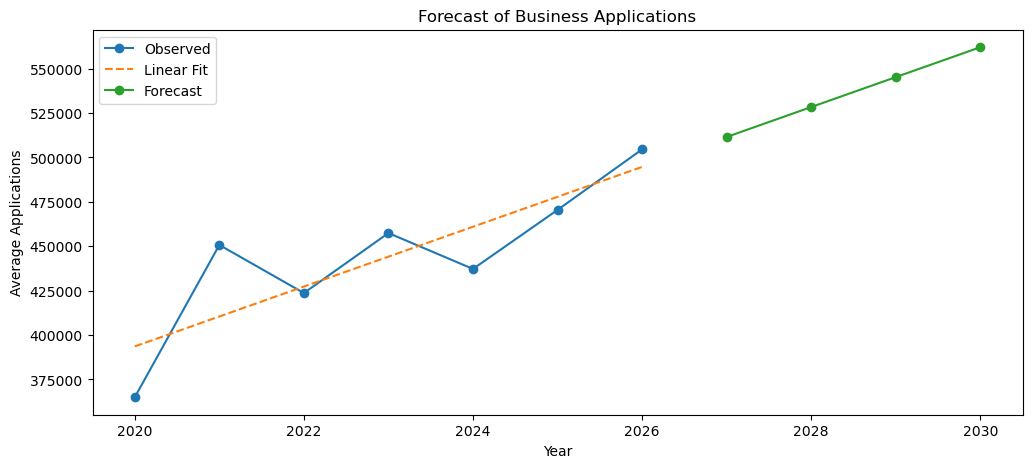

In [126]:
annual_post["prediction"] = model.predict(X)

plt.figure(figsize=(12,5))

plt.plot(
    annual_post["year"],
    annual_post["value"],
    marker="o",
    label="Observed"
)

plt.plot(
    annual_post["year"],
    annual_post["prediction"],
    linestyle="--",
    label="Linear Fit"
)

plt.plot(
    future_years["year"],
    future_years["forecast"],
    marker="o",
    label="Forecast"
)

plt.title("Forecast of Business Applications")
plt.xlabel("Year")
plt.ylabel("Average Applications")
plt.legend()

plt.show()

## Optional Forecasting Extension

**Interpretation**

Two simple linear regression models were fitted to annual business application counts. The first model used the entire 2004–2026 period, while the second used only post-pandemic observations (2020–2026). The post-COVID model produced substantially higher forecasts through 2030, suggesting that recent business formation patterns differ from those observed before 2020. Although these forecasts should be interpreted cautiously, the results provide additional evidence of a structural shift in business application activity following the COVID-19 period.